In [1]:
import inspect
import io

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


## Distintas funciones a optimizar

In [2]:
def rosenback(v, **kwargs):
    """
    f(x, y) = (a - x)² + b (y - x²)²

    Default kwargs:
        a: 1
        b: 100
    """
    x, y = v
    a = kwargs.get("a", 1)
    b = kwargs.get("b", 100)
    return (a - x) ** 2 + b * (y - x**2) ** 2


def himmelblau(v, **kwargs):
    """
    f(x, y) = (x² + y - a)² + (x + y² - b)²

    Default kwargs:
        a: 11
        b: 7
    """
    x, y = v
    a = kwargs.get("a", 11)
    b = kwargs.get("b", 7)
    return (x**2 + y - a) ** 2 + (x + y**2 - b) ** 2


def quadratic(v, **kwargs):
    """
    f(x, y) = a x² + b y² + c

    Default kwargs:
        a: 1
        b: 3
        c: 5
    """
    x, y = v
    a = kwargs.get("a", 1)
    b = kwargs.get("b", 3)
    c = kwargs.get("c", 5)
    return a * x**2 + b * y**2 + c


def booth(v, **kwargs):
    """
    f(x, y) = (x + a y - b)² + (c x + y - d)²

    Default kwargs:
        a: 2
        b: 7
        c: 1
        d: 5
    """
    x, y = v
    a = kwargs.get("a", 2)
    b = kwargs.get("b", 7)
    c = kwargs.get("c", 1)
    d = kwargs.get("d", 5)
    return (x + a * y - b) ** 2 + (c * x + y - d) ** 2


def beale(v, **kwargs):
    """
    f(x, y) = (a - x + x y)² + (b - x + x y²)² + (c - x + x y³)²

    Default kwargs:
        a: 1.5
        b: 2.25
        c: 2.625
    """
    x, y = v
    a = kwargs.get("a", 1.5)
    b = kwargs.get("b", 2.25)
    c = kwargs.get("c", 2.625)
    return (a - x + x * y) ** 2 + (b - x + x * y**2) ** 2 + (c - x + x * y**3) ** 2


def three_hump_camel(v, **kwargs):
    """
    f(x, y) = a x² - b x⁴ + xᶜ / 6 + x y + y²

    Default kwargs:
        a: 2
        b: 1.05
        c: 6
    """
    x, y = v
    a = kwargs.get("a", 2)
    b = kwargs.get("b", 1.05)
    c = kwargs.get("c", 6)
    return a * x**2 - b * x**4 + x**c / 6 + x * y + y**2


def matyas(v, **kwargs):
    """
    f(x, y) = a (x² + y²) - b x y

    Default kwargs:
        a: 0.26
        b: 0.48
    """
    x, y = v
    a = kwargs.get("a", 0.26)
    b = kwargs.get("b", 0.48)
    return a * (x**2 + y**2) - b * x * y


def sphere(v, **kwargs):
    """
    f(x, y) = c (xᵃ + yᵇ) + d

    Default kwargs:
        a: 2
        b: 2
        c: 1
        d: 0
    """
    x, y = v
    a = kwargs.get("a", 2)
    b = kwargs.get("b", 2)
    c = kwargs.get("c", 1)
    d = kwargs.get("d", 0)
    return c * (x**a + y**b) + d


def ackley(v, **kwargs):
    """
    f(x, y) = -a exp(-b sqrt((x² + y²)/2)) - exp((cos(c x) + cos(c y))/2) + a + e

    Default kwargs:
        a: 20
        b: 0.2
        c: 2π
    """
    x, y = v
    a = kwargs.get("a", 20)
    b = kwargs.get("b", 0.2)
    c = kwargs.get("c", 2 * np.pi)
    term1 = -a * np.exp(-b * np.sqrt(0.5 * (x**2 + y**2)))
    term2 = -np.exp(0.5 * (np.cos(c * x) + np.cos(c * y)))
    return term1 + term2 + a + np.e


def levi(v, **kwargs):
    """
    f(x, y) = sin(a π x)² + (x - b)² [1 + sin(c π y)²] + (y - d)² [1 + sin(e π y)²]

    Default kwargs:
        a: 3
        b: 1
        c: 3
        d: 1
        e: 2
    """
    x, y = v
    a = kwargs.get("a", 3)
    b = kwargs.get("b", 1)
    c = kwargs.get("c", 3)
    d = kwargs.get("d", 1)
    e = kwargs.get("e", 2)
    return (
        np.sin(a * np.pi * x) ** 2
        + (x - b) ** 2 * (1 + np.sin(c * np.pi * y) ** 2)
        + (y - d) ** 2 * (1 + np.sin(e * np.pi * y) ** 2)
    )


def rastrigin(v, **kwargs):
    """
    f(x, y) = A n + sum[xᵢ² − A cos(2 π xᵢ)]

    Default kwargs:
        A: 10
    """
    A = kwargs.get("A", 10)
    n = v.size
    return A * n + np.sum(v**2 - A * np.cos(2 * np.pi * v), axis=0)


def styblinski_tang(v, **kwargs):
    """
    f(x, y) = sum[(xᵢ⁴ − 16 xᵢ² + 5 xᵢ) / 2]
    """
    return np.sum((v**4 - 16 * v**2 + 5 * v) / 2, axis=0)


def michalewicz(v, **kwargs):
    """
    f(x, y) = −sum[ sin(xᵢ) sin⁽²ᵐ⁾( i xᵢ² / π ) ]

    Default kwargs:
        m: 10
    """
    m = kwargs.get("m", 10)
    dims = v.shape[0]
    i = np.arange(1, dims + 1).reshape(dims, 1, 1)
    return -np.sum(np.sin(v) * np.sin(i * v**2 / np.pi) ** (2 * m), axis=0)


def schwefel(v, **kwargs):
    """
    f(x, y) = 418.9829 n − sum[ xᵢ sin( sqrt(|xᵢ|) ) ]
    """
    n_dims = v.shape[0]
    return 418.9829 * n_dims - np.sum(v * np.sin(np.sqrt(np.abs(v))), axis=0)


def griewank(v, **kwargs):
    """
    f(x, y) = 1 + sum[xᵢ² / 4000] − prod[ cos( xᵢ / sqrt(i) ) ]
    """
    dims = v.shape[0]
    i = np.arange(1, dims + 1).reshape(dims, 1, 1)
    return 1 + np.sum(v**2 / 4000, axis=0) - np.prod(np.cos(v / np.sqrt(i)), axis=0)


def zakharov(v, **kwargs):
    """
    f(x, y) = sum[xᵢ²] + (0.5 sum[i xᵢ])² + (0.5 sum[i xᵢ])⁴
    """
    dims = v.shape[0]
    i = np.arange(1, dims + 1).reshape(dims, 1, 1)
    s = 0.5 * np.sum(i * v, axis=0)
    return np.sum(v**2, axis=0) + s**2 + s**4


def easom(v, **kwargs):
    """
    f(x, y) = −cos(x) cos(y) exp( −[(x − π)² + (y − π)²] )
    """
    x, y = v
    return -np.cos(x) * np.cos(y) * np.exp(-((x - np.pi) ** 2 + (y - np.pi) ** 2))


def eggholder(v, **kwargs):
    """
    f(x, y) = −(y + 47) sin( sqrt(|x/2 + y + 47|) ) − x sin( sqrt(|x − (y + 47)|) )
    """
    x, y = v
    return -(y + 47) * np.sin(np.sqrt(np.abs(x / 2 + y + 47))) - x * np.sin(
        np.sqrt(np.abs(x - (y + 47)))
    )


def perm(v, **kwargs):
    """
    f(x) = sum_j sum_i (iⁿ + jⁿ) ( (xᵢ / i)ʲ − 1 )²

    Default kwargs:
        n: 2
    """
    n = kwargs.get("n", 2)

    if v.ndim == 1:
        d = v.size
        total = 0.0
        for j in range(1, d + 1):
            inner = 0.0
            for i in range(1, d + 1):
                inner += (i**n + j**n) * ((v[i - 1] / i) ** j - 1) ** 2
            total += inner
        return total

    dims = v.shape[0]
    i = np.arange(1, dims + 1).reshape(dims, 1, 1)

    total = np.zeros(v.shape[1:], dtype=v.dtype)
    for j in range(1, dims + 1):
        coeff = i**n + j**n
        inner = coeff * ((v / i) ** j - 1) ** 2
        total += np.sum(inner, axis=0)

    return total


def create_contour_plot(
    function: callable,
    x_range: tuple[float, float],
    y_range: tuple[float, float],
    save: bool = False,
    clevels: int = 100,
    tolerance: float = 1e-3,
    ax: plt.Axes | None = None,
    **func_kwargs,
):

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    else:
        fig = ax.figure

    x = np.linspace(x_range[0], x_range[1], 300)
    y = np.linspace(y_range[0], y_range[1], 300)
    X, Y = np.meshgrid(x, y)

    Z = function(np.array([X, Y]), **func_kwargs)

    contour = ax.contourf(X, Y, Z, levels=clevels, cmap="YlOrRd")
    fig.colorbar(contour, ax=ax, label="Objective Function Value")

    ax.set_xlabel("x")
    ax.set_ylabel("y")

    absolute_min = np.min(Z)

    minima_mask = np.abs(Z - absolute_min) <= tolerance
    i_coords, j_coords = np.where(minima_mask)

    for i, j in zip(i_coords, j_coords):
        ax.plot(X[i, j], Y[i, j], "b*", markersize=9, markeredgewidth=1)

    if not save:
        return fig, ax

    buf = io.BytesIO()
    fig.savefig(buf, format="png")
    buf.seek(0)
    img = Image.open(buf)
    plt.close(fig)
    return img


(<Figure size 800x600 with 2 Axes>, <Axes: xlabel='x', ylabel='y'>)

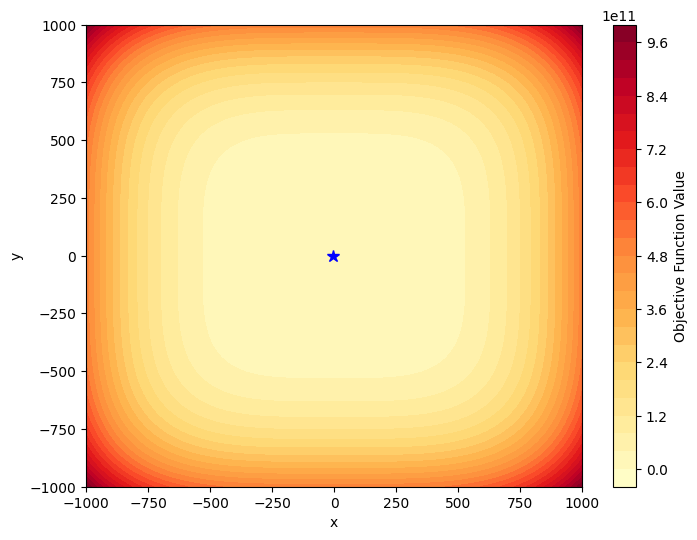

In [15]:
"""
rosenback => a: 1 / b: 100
himmelblau => a: 11 / b: 7
quadratic => a: 1 / b: 3 / c: 5
booth => a: 2 / b: 7 / c: 1 / d: 5
beale => a: 1.5 / b: 2.25 / c: 2.625
three_hump_camel => a: 2 / b: 1.05 / c: 6
matyas => a: 0.26 / b: 0.48
sphere => a: 2 / b: 2 / c: 1 / d: 0
ackley => a: 20 / b: 0.2 / c: 2π
levi => a: 3 / b: 1 / c: 3 / d: 1 / e: 2
rastrigin =>
styblinski_tang =>
michalewicz =>
schwefel =>
griewank =>
zakharov =>
easom =>
eggholder =>
rosenbrock_ndim =>
perm =>

"""

create_contour_plot(styblinski_tang, (-1000, 1000), (-1000, 1000), clevels=30)

## Optimización con Nelder-Mead

### Definiciones

- Se parte de un espacio de `n` dimensiones: $\mathbb{R}^n$.

- Símplex no degenerado. En un espacio $\mathbb{R}^n$, es la envolvente convexa de `n+1` puntos no coplanares ${x_i}$, donde $i \in [1, n+1]$. 
Esto implica que no todos los puntos están en un mismo hiperplano de $\mathbb{R}^n$.

- Los vértices del simplex inicial $x_1, ... x_{n+1}$ están ordenados de modo que: $f_1 \leq f_2 \leq ... \leq f_{n+1}$, donde $f_i = f(x_i)$.

- Como el objetivo es minimizar `f`, $x_1$ es el mejor vértice y $x_{n+1}$ el peor.

- El diámetro del simplex $\mathcal{S}$  es: $diam(\mathcal{S})=max_{1 \leq i, j \leq n+1}(||x_i − x_j||)$

- En cada paso de la iteración se emplearán los siguientes parámetros:

    - Para la reflexión: $0 < \rho < \delta$. Típicamente se emplea $\rho=1$.
    - Para la expansión: $\delta > 1$. Típicamente se emplea $\delta=2$.
    - Para la contracción: $0 < \gamma < 1$. Típicamente se emplea $\gamma=\frac{1}{2}$.
    - Para la reducción: $0 < \sigma < 1$. Típicamente se emplea $\sigma=\frac{1}{2}$.

### Paso a paso del algoritmo

1. ***ORDENAR***. 

    Se ordenan los n+1 vértices del simplex $\mathcal{S}$, de menor a mayor valor (por ser un problema de minimización).

2. ***REFLEJAR***. 

    a. Se calcula el *centroide* de los n mejores puntos: $\hat{x}=\sum_{i=1}^n \frac{x_i}{n}$

    b. Se calcula el *punto de reflexión*
    $$ x_r=\hat{x} + \rho (\hat{x}-x_{n+1}) = (1+\rho)\hat{x} - \rho x_{n+1} $$

    c. Se calcula $f_r=f(x_r)$. Si $f_1 \leq f_r < f_n$, se acepta $x_r$ como nuevo vértice del simplex $\mathcal{S}$ . Se elimina entonces el peor vértice y se finaliza la iteración

3. ***EXPANDIR***. 
    
    Si $f_r < f_1$ (nuevo mejor vértice), se calcula el *punto de expansión*
    $$x_e = \hat{x} + \delta(x_r-\hat{x}) = \hat{x} + \rho\delta(\hat{x}-x_{n+1}) = (1+\rho\delta)\hat{x}-\rho\delta x_{n+1}$$
    y se evalúa $f_e = f(x_e)$. Si $f_e<f_r$ se acepta $x_e$, eliminando el peor vértice y terminando la iteración. En caso de que no sea así ($f_e \geq f_r$), se acepta $x_r$, eliminando el peor vértice y terminando la iteración.
    

4. ***CONTRAER***

    Si $f_r \geq f_n$, se realiza una contracción entre $\hat{x}$ y el mejor entre $x_{n+1}$ y $x_r$.

    **4.a) Contracción externa**. 
    Si $f_n \leq f_r < f_{n+1}$, se calcula
    $$ x_{ce} = \hat{x} + \gamma(x_r-\hat{x}) = \hat{x} + \rho\gamma(\hat{x}-x_{n+1}) = (1+\rho\gamma) \hat{x} - \rho\gamma x_{n+1}$$
    y se evalúa $f_{ce}=f(x_{ce})$. Si $f_{ce} \leq f_r$, se acepta $x_{ce}$, eliminando el peor vértice y terminando la iteración. En caso contrario, se va al **Paso 5**.

    **4.b) Contracción interna**.
    Si $f_r \geq f_{n+1}$, se calcula
    $$x_{ci} = \hat{x} - \gamma(\hat{x}-x_{n+1}) = (1-\gamma) \hat{x} + \gamma x_{n+1}$$
    y se evalúa $f_{ci}=f(x_{ci})$. Si $f_{ci}<f_{n+1}$, se acepta $x_{ci}$, eliminando el peor vértice y terminando la iteración. En caso contrario, se va al **Paso 5**.

5. ***ENCOGER***

    Se evalúa $f$ en los $n$ puntos $y_i = x_1 + \sigma (x_i - x_1)$, $i=\{2, ..., n+1\}$. Los nuevos vértices del simplex $\mathcal{S}$  en la próxima iteración serán $x_1, y_2, ..., y_{n+1}$

![alt text](https://c.mql5.com/2/61/NMrefl.png)

### Condiciones de parada

Las iteraciones del método pueden detenerse cuando se cumpla alguno (o varios) de los siguientes criterios:

1. El diámetro del símplex se hace suficientemente pequeño:  $diam(\mathcal{S}) < \varepsilon_1$, donde $\varepsilon_1$ es una tolerancia predefinida.
2. La variación de los valores de la función entre los vértices es muy reducida: $\max_i f_i - \min_i f_i < \varepsilon_2$.
3. Se alcanza un número máximo de iteraciones o de evaluaciones de la función objetivo.


### Recomendaciones sobre el símplex inicial

La elección del símplex inicial influye en la estabilidad y la velocidad de convergencia del método. Algunas recomendaciones son:

1. Seleccionar los puntos iniciales de modo que el símplex tenga un tamaño moderado, evitando formas degeneradas.  
2. Ajustar la escala del símplex a la magnitud de las variables del problema.  
3. Utilizar un símplex inicial suficientemente grande para explorar el espacio, pero no tan grande como para provocar saltos ineficaces o inestables.

### Propiedades técnicas

El método Nelder-Mead opera de forma puramente geométrica, **sin necesidad de gradientes** ni derivadas. Todas las transformaciones (reflexión, expansión, contracción y encogimiento) manipulan la forma y el tamaño del símplex para aproximarse a un mínimo local.

La carga computacional está dominada por las evaluaciones de la función objetivo y no por los cálculos geométricos. Por ello, el método es **adecuado** para problemas donde **cada evaluación de $f$ es costosa**, aunque no es recomendable para funciones extremadamente ruidosas.

Los parámetros influyen directamente en la agresividad de las transformaciones:

1. Valores grandes de $\delta$ producen expansiones más pronunciadas.  
2. Valores pequeños de $\gamma$ originan contracciones más suaves y conservadoras.

### Advertencias

El método Nelder-Mead **no garantiza convergencia global**.  
En dimensión dos, existen resultados de convergencia bajo hipótesis adicionales, pero en general el método debe considerarse heurístico.

La ausencia de derivadas lo hace **robusto frente a funciones no suaves**, pero a la vez **puede comportarse de forma errática** si la función presenta ruido significativo. Asimismo, no es adecuado para problemas con múltiples mínimos muy cercanos entre sí.

### Interpretación geométrica

El algoritmo manipula un símplex en el espacio $\mathbb{R}^n$, desplazándolo, expandiéndolo o contrayéndolo según el comportamiento local de la función objetivo. La dinámica del símplex permite explorar la región circundante y, mediante ajustes sucesivos en su forma y tamaño, aproximarse a un mínimo local sin utilizar información de gradiente.

[![](https://mermaid.ink/img/pako:eNqFVMty2kAQ_JWpTfmUBUs8LKw4doEQNjYIDE5VKuDDWlrBxkJLVhImwRzyDfmCHHPIKbdcUmV-LKuHBXYlZQ5A7_R0z7QeK2RzhyIduR6_s6dEhHDVHPsgP_VR22c2I0IH6tEJExCw2dyjS2DJuXcNhcIxNEbmgngREeBGvs02v3ygPng8gMXmhwiZTYPrVLCR8I1RTzjUl_y8rh_diP1jV4Wjt1AsFuMf10-_X6tZs5E0N0cG8ezIk90D6nr0I4elyBjNhGGuHv6YgZwYZrIqTlJpAUfgquuxn1L39sCod9tWD5ommO_7dWvY3nyz0qIZ69wPNz_vobW1M5dz4gfJekuaObYSx9PYcVtNbAnMNt-DzJzG5mKd9pxu1c9GdZvOw_-Ip0SL30M75z3Z-fkq5vBq89Vq1gfQA6NnXQ3qhvF8q1juXM7bp1zAp4jGOZUefsOc7kR1HAefZ3W-HfhiG4fB_VAQO73eSzub-SIJpCMNntTTSDJ9O05DXtcsj85Wvpvv-W_1Tr6CNRpQJ8rq-zCcCubfXj-dOOb1Xkiu8c7omNBqW_VOenaWLNAfyQUEC6lgHBwKcyKIQ06yMdopJwXdXdDbBdYjSGE_H6qxe5AsfjlqMV-XTgvuLaiA5eNNnw9qBiGTj1SKbY8EQZO6ssFmAeM-uMzz9Feu6x7aFRyEgt9SCW9speRksHDHnHCql-ZLbHOPC_2VoihvnukRO9yqUdWtujRXU0qadvOS2o4emPgUn-MO7udj7tpBHTewgZu4hc9wG1_gLrZwD19mM0gqwmgimIP0UEQUoxkVMxJDtIplxiic0hkdI13-dYi4HaOxv5Y98kH6wPnssU3waDJFuku8QKJo7pCQNhmZCLKlUN-hwuCRHyK9oqiJBtJXaIn0UlUpakqlohxo5VqpppaqGH1GeqGsqsVyuVZWtZqmKodlrbrG6EviqxZLB5paU8sHaq2iVA-rNYyow0IuuumbNnnhrv8CYtG9Ww?type=png)](https://mermaid.live/edit#pako:eNqFVMty2kAQ_JWpTfmUBUs8LKw4doEQNjYIDE5VKuDDWlrBxkJLVhImwRzyDfmCHHPIKbdcUmV-LKuHBXYlZQ5A7_R0z7QeK2RzhyIduR6_s6dEhHDVHPsgP_VR22c2I0IH6tEJExCw2dyjS2DJuXcNhcIxNEbmgngREeBGvs02v3ygPng8gMXmhwiZTYPrVLCR8I1RTzjUl_y8rh_diP1jV4Wjt1AsFuMf10-_X6tZs5E0N0cG8ezIk90D6nr0I4elyBjNhGGuHv6YgZwYZrIqTlJpAUfgquuxn1L39sCod9tWD5ommO_7dWvY3nyz0qIZ69wPNz_vobW1M5dz4gfJekuaObYSx9PYcVtNbAnMNt-DzJzG5mKd9pxu1c9GdZvOw_-Ip0SL30M75z3Z-fkq5vBq89Vq1gfQA6NnXQ3qhvF8q1juXM7bp1zAp4jGOZUefsOc7kR1HAefZ3W-HfhiG4fB_VAQO73eSzub-SIJpCMNntTTSDJ9O05DXtcsj85Wvpvv-W_1Tr6CNRpQJ8rq-zCcCubfXj-dOOb1Xkiu8c7omNBqW_VOenaWLNAfyQUEC6lgHBwKcyKIQ06yMdopJwXdXdDbBdYjSGE_H6qxe5AsfjlqMV-XTgvuLaiA5eNNnw9qBiGTj1SKbY8EQZO6ssFmAeM-uMzz9Feu6x7aFRyEgt9SCW9speRksHDHnHCql-ZLbHOPC_2VoihvnukRO9yqUdWtujRXU0qadvOS2o4emPgUn-MO7udj7tpBHTewgZu4hc9wG1_gLrZwD19mM0gqwmgimIP0UEQUoxkVMxJDtIplxiic0hkdI13-dYi4HaOxv5Y98kH6wPnssU3waDJFuku8QKJo7pCQNhmZCLKlUN-hwuCRHyK9oqiJBtJXaIn0UlUpakqlohxo5VqpppaqGH1GeqGsqsVyuVZWtZqmKodlrbrG6EviqxZLB5paU8sHaq2iVA-rNYyow0IuuumbNnnhrv8CYtG9Ww)

In [13]:
from nelder_mead import *

parameters = NelderMeadParameters()
optimizer = NelderMead(parameters)
visualizer = NelderMeadVisualizer()

obj_function = griewank
res = optimizer.optimize(
    obj_function, x0=np.array([-5, 5]), track_history=True, verbose=True
)
visualizer.plot_optimization_2d(
    res, obj_function, ((-1000, 1000), (-1000, 1000)), n_points=1000, show_contours=False
);
# <-- Check its parameters
# visualizer.animate_optimization_2d(res, obj_function, ((-10, 10), (-10, 10)), interval=250)


ValueError: setting an array element with a sequence.

```mermaid
flowchart TD
    A[Iniciar: elegir simplex inicial] --> B[Evaluar función en los vértices]
    B --> C[Ordenar vértices:<br/>f1 <= ... <= fn <= fn+1]
    C --> D[Calcular Reflejo xr]
    D --> E{¿Es el mejor?<br/>fr < f1}

    %% CAMINO DE EXPANSIÓN
    E -->|Sí| F[Calcular Expansión xe]
    F --> G{¿Expansión mejora más?<br/>fe < fr}
    G -->|Sí| H[Aceptar Expansión xe]
    G -->|No| I[Aceptar Reflejo xr]

    %% CAMINO ESTÁNDAR O CONTRACCIÓN
    E -->|No| J{¿Peor que el 2º peor?<br/>fr >= fn}

    J -->|Sí| K[Calcular Contracción xc]
    K --> L{¿Contracción mejora?<br/>fc < fn+1}
    L -->|Sí| M[Aceptar Contracción xc]
    L -->|No| N[Reducción / Shrink]

    J -->|No| O[Aceptar Reflejo xr]

    %% BUCLE FINAL
    H --> P[¿Criterio de parada?]
    I --> P
    M --> P
    O --> P
    N --> P

    P -->|No| B
    P -->|Sí| Q[Fin: devolver x1]
    
    %% Estilos
    classDef decision fill:#fff9c4,stroke:#fbc02d,stroke-width:2px,color:#000;
    classDef action fill:#e1f5fe,stroke:#0277bd,stroke-width:2px,color:#000;

    class E,G,J,L,P decision;
    class A,B,C,D,F,H,I,K,M,N,O,Q action;
```